In [3]:
import time
import datetime
import random
import numpy as np
import polars as pl
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import seaborn as sns

In [2]:
interactions = pl.read_ipc('./data/goodreads_interactions.feather')

In [3]:
interactions_by_book = interactions.group_by('book_id').sum().filter(pl.col('rating').ne(0))['book_id']
interactions = interactions.filter(pl.col('book_id').is_in(interactions_by_book.implode()))

In [4]:
interactions = interactions.filter(pl.col('is_read').eq(1))
interactions = interactions.drop('is_read')
interactions = interactions.filter(pl.col('user_id').is_duplicated())

In [5]:
def normalize_ids(df: pl.DataFrame, id: str):
    uniq_ids = set(df[id].unique())
    ids_to_indices = { orig_id : new_id for new_id, orig_id in enumerate(uniq_ids) }
    new_ids = df.with_columns(pl.col(id).replace(ids_to_indices).cast(pl.Int64))
    indices_to_ids = { new_id : orig_id for orig_id, new_id in ids_to_indices.items()}
    return new_ids, indices_to_ids

In [6]:
interactions, _ = normalize_ids(interactions, 'user_id')
interactions, _ = normalize_ids(interactions, 'book_id')

interactions_n_books = interactions['book_id'].n_unique()

In [7]:
gss = GroupShuffleSplit(n_splits=5)

interactions_train_idx, interactions_test_idx = next(gss.split(X=interactions, groups=interactions['user_id']))
interactions_train: pl.DataFrame = interactions[interactions_train_idx]
interactions_test:  pl.DataFrame = interactions[interactions_test_idx]

In [8]:
interactions_train, interactions_train_map_id = normalize_ids(interactions_train, 'user_id')
interactions_test,  interactions_test_map_id  = normalize_ids(interactions_test, 'user_id')

interactions_train_csr = csr_matrix((interactions_train['rating'], (interactions_train['user_id'], interactions_train['book_id'])), shape=(interactions_train['user_id'].n_unique(), interactions_n_books))

In [9]:
interactions_test_seen,   interactions_test_unseen         = train_test_split(interactions_test, train_size=0.7, stratify=interactions_test['user_id'])

interactions_test_seen,   interactions_test_seen_map_id    = normalize_ids(interactions_test_seen,   'user_id')
interactions_test_unseen, interactions_test_unseen_map_id  = normalize_ids(interactions_test_unseen, 'user_id')

interactions_test_seen_csr = csr_matrix((interactions_test_seen['rating'], (interactions_test_seen['user_id'], interactions_test_seen['book_id'])), shape=(interactions_test_seen['user_id'].n_unique(), interactions_n_books))

In [10]:
def create_kn(k, train, test, metric='cosine', n_jobs=24, return_distance=False):
    nn = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=n_jobs)
    nn.fit(train)
    return nn.kneighbors(test, return_distance=return_distance)

In [11]:
def k_average_ratings(train_df: pl.DataFrame, test_seen_df: pl.DataFrame, test_unseen_df: pl.DataFrame, train_map_id, test_map_id, kn, k):
    kn_idx = kn[:, :k]
    nn = pl.DataFrame({ 'neighbor_idx' : kn_idx.reshape(-1), 'query_idx' : np.arange(test_seen_df['user_id'].n_unique()).repeat(k)})
    nb = nn.with_columns((pl.col('neighbor_idx').replace(train_map_id).alias('training_user_id'), pl.col('query_idx').replace(test_map_id).alias('query_user_id'))).select(['training_user_id', 'query_user_id'])
    tf = train_df.lazy().filter(pl.col('user_id').is_in(nb['training_user_id'].implode()))
    jn = tf.join(nb.lazy(), left_on='user_id', right_on='training_user_id').select('query_user_id', 'book_id', 'rating')
    pd = jn.group_by(['query_user_id', 'book_id'])
    pa = pd.agg(pl.col('rating').mean()).rename({ 'query_user_id': 'user_id', 'rating': 'pred_rating' })
    pf = pa.filter(pl.col('user_id').is_in(test_unseen_df['user_id'].implode()) & pl.col('book_id').is_in(test_unseen_df['book_id'].implode()))
    rt = pf.join(test_unseen_df.lazy(), on=['user_id', 'book_id']).filter(pl.col('rating').is_not_null()).collect(engine="streaming")
    pr = pearsonr(rt['pred_rating'].to_numpy(), rt['rating'].to_numpy())
    return pr.statistic ** 2

In [12]:
interactions_kn = create_kn(500, interactions_train_csr, interactions_test_seen_csr)

In [13]:
interactions_pr_5 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=5)
print(f'k=5 R^2: {interactions_pr_5}')

k=5 R^2: 0.004913415476265486


In [14]:
interactions_pr_10 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=10)
print(f'k=10 R^2: {interactions_pr_10}')

k=10 R^2: 0.004544303873646272


In [15]:
interactions_pr_25 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=25)
print(f'k=25 R^2: {interactions_pr_25}')

k=25 R^2: 0.004265593536934755


In [16]:
interactions_pr_50 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=50)
print(f'k=50 R^2: {interactions_pr_50}')

k=50 R^2: 0.004370469571998291


In [17]:
interactions_pr_100 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=100)
print(f'k=100 R^2: {interactions_pr_100}')

k=100 R^2: 0.004938146822214421


In [18]:
interactions_pr_150 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=150)
print(f'k=150 R^2: {interactions_pr_150}')

k=150 R^2: 0.005453482889852438


In [19]:
interactions_pr_200 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=200)
print(f'k=200 R^2: {interactions_pr_200}')

k=200 R^2: 0.005843752272610795


In [20]:
interactions_pr_250 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=250)
print(f'k=250 R^2: {interactions_pr_250}')

k=250 R^2: 0.0062082305323854425


In [21]:
interactions_pr_350 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=350)
print(f'k=350 R^2: {interactions_pr_350}')

k=350 R^2: 0.006712953501996154


In [22]:
interactions_pr_500 = k_average_ratings(train_df=interactions_train,
                               test_seen_df=interactions_test_seen,
                               test_unseen_df=interactions_test_unseen,
                               train_map_id=interactions_train_map_id,
                               test_map_id=interactions_test_seen_map_id,
                               kn=interactions_kn,
                               k=500)
print(f'k=500 R^2: {interactions_pr_500}')

: 

: 

[Text(0.5, 1.0, 'Without Filtering'), Text(0.5, 0, 'K'), Text(0, 0.5, 'R2')]

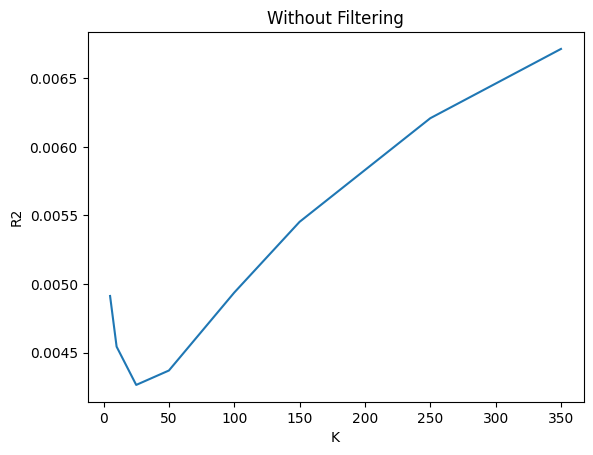

In [13]:
r2s = {
    5: 0.004913415476265486,
    10: 0.004544303873646272,
    25: 0.004265593536934755,
    50: 0.004370469571998291,
    100: 0.004938146822214421,
    150: 0.005453482889852438,
    250: 0.0062082305323854425,
    350: 0.006712953501996154
}
sns.lineplot(r2s).set(title='Without Filtering', xlabel='K', ylabel='R2')

In [17]:
filtered10_r2s = {
    5: 0.09013848164008283,
    10: 0.09744380222067169,
    25: 0.11092274482695903,
    50: 0.12318157457699902,
    100: 0.13554620409461057,
    150: 0.1427469439371413,
    250: 0.15054756716580708,
    350: 0.15475951694204013
}

[Text(0.5, 1.0, 'Filtered to Require 10+ Reviews'),
 Text(0.5, 0, 'K'),
 Text(0, 0.5, 'R2')]

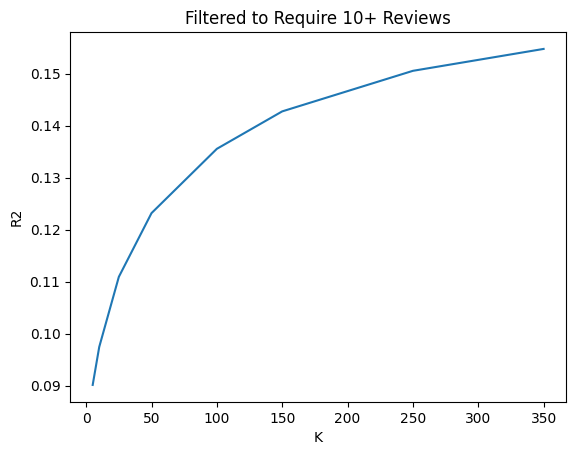

In [ ]:
sns.lineplot(filtered10_r2s).set(title='Filtered to Require 10+ Reviews', xlabel='K', ylabel='R2')

[Text(0.5, 1.0, 'KNN R2 Scores'), Text(0.5, 0, 'K'), Text(0, 0.5, 'R2')]

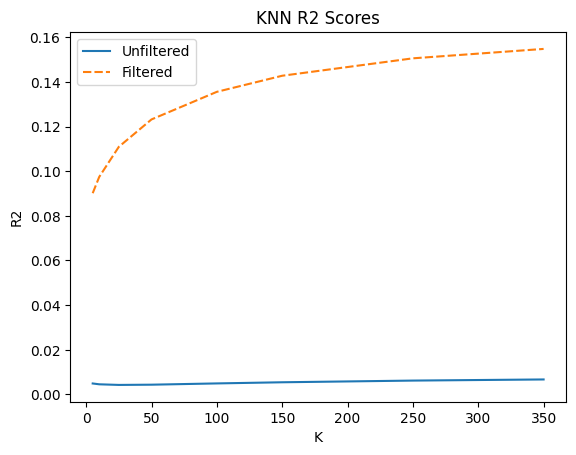

In [12]:
sns.lineplot({'Unfiltered':r2s, 'Filtered':filtered_r2s}).set(title='KNN R2 Scores', xlabel='K', ylabel='R2')

In [20]:
filtered2_r2s = {
    5: 0.09547828312552188,
    10: 0.10151315408911078,
    25: 0.11498517324860201,
    50: 0.12784978391843244,
    100: 0.1400365702862341,
    150: 0.14683753955649304,
    250: 0.1541621301331749,
    350: 0.158401611682562,
    # 500: 0.16330772721539147
}

[Text(0.5, 1.0, 'Sampled KNN'), Text(0.5, 0, 'K'), Text(0, 0.5, 'R2')]

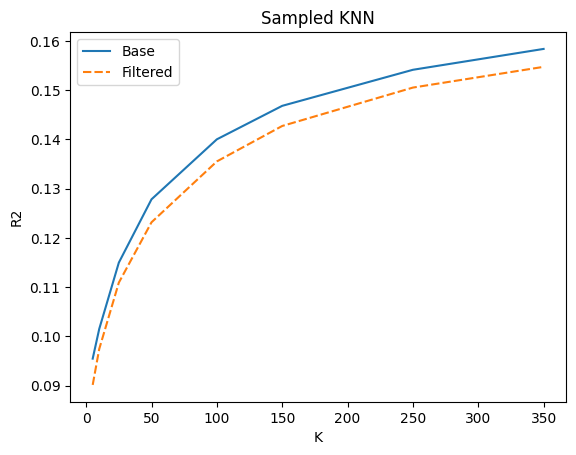

In [21]:
sns.lineplot({'Base':filtered2_r2s, 'Filtered':filtered10_r2s}).set(title='Sampled KNN', xlabel='K', ylabel='R2')